In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os
import pandas as pd
import seaborn as sns

In [62]:
hdffiles = []
for path, dirs, files in os.walk("data"):
    if len(files) == 2:
        name = path.split("\\")[-1]
        print(name)
        data = h5py.File(path + "/dataset.hdf5", "r")
        fields = {}
        for key in data.keys():
            if "units" in data[key].attrs:
                fieldname = data[key].attrs["long_name"] + " (" + data[key].attrs["units"] + ")"
                fields[fieldname] = data[key]
            else:
                print("No units for "   + key)
                # fieldname = "dim_0"
            
        hdffiles.append([name, pd.DataFrame(data=fields)])

20260916-085023-336-2969a5-Resonator spectroscopy VNA (power=0 dBm)
No units for dim_0
20260916-085750-917-27fcbf-Resonator spectroscopy VNA (power=0 dBm)
No units for dim_0
20260916-090230-399-b6baa1-Resonator spectroscopy VNA (power=0 dBm)
No units for dim_0
20260916-091319-425-4726a2-Punchout VNA (6.8489-6.8589 GHz)
No units for dim_0
20260916-091752-780-e4763e-Punchout VNA (6.8529-6.8549 GHz)
No units for dim_0
20260916-091923-521-4c39c1-Punchout VNA (6.8534-6.8554 GHz)
No units for dim_0
20260916-092239-638-a43d1f-Punchout VNA (6.8534-6.8554 GHz)
No units for dim_0
20260916-092405-625-ae1a3d-Punchout VNA (6.8534-6.8554 GHz)
No units for dim_0
20260916-094653-444-0d3de8-Two-tone spec power sweep VNA q2 (vna_freq=6.8550 GHz)
No units for dim_0
20260916-095636-257-6d5c01-Two-tone spec power sweep VNA q2 (vna_freq=6.8550 GHz)
No units for dim_0
20260923-084343-796-08f621-Parallel attenuation sweep ['q2']
No units for dim_0
20260923-084554-219-5651a8-Parallel attenuation sweep ['q2']
N

        vna Power (dBm)  VNA sweep frequency (Hz)  S21 real (ratio)  \
0                 -30.0              6.848925e+09          0.266235   
1                 -30.0              6.848935e+09          0.269338   
2                 -30.0              6.848945e+09          0.267304   
3                 -30.0              6.848955e+09          0.264746   
4                 -30.0              6.848965e+09          0.271683   
...                 ...                       ...               ...   
100095             10.0              6.858885e+09         -0.241081   
100096             10.0              6.858895e+09         -0.240384   
100097             10.0              6.858905e+09         -0.239779   
100098             10.0              6.858915e+09         -0.239117   
100099             10.0              6.858925e+09         -0.238405   

        S21 imag (ratio)  freq_index (#)  
0               0.081562               0  
1               0.077554               1  
2               0.

<Axes: xlabel='vna Power (dBm)', ylabel='VNA sweep frequency (Hz)'>

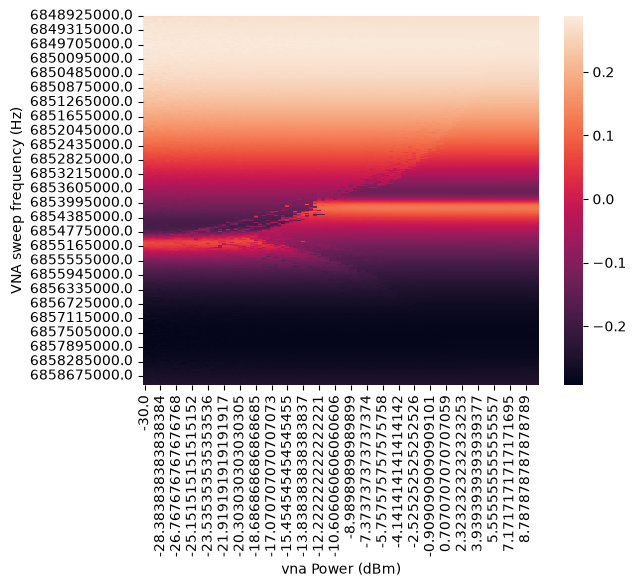

In [79]:
# hdffiles[0][1].keys()
#Index(['freq_index (#)', 'S21 real (ratio)', 'S21 imag (ratio)'], dtype='str')

d = hdffiles[3][1]
# plt.plot(d["freq_index (#)"], d["S21 real (ratio)"], label="real")
print(d)
# plt.scatter(d["dim_0"], d["Frequency of readout pulse (Hz)"])
# sns.heatmap(data=d, x="vna Power (dBm)", y="VNA sweep frequency (Hz)", values="S21 real (ratio)")
# d.pivot_table(index="VNA sweep frequency (Hz)", columns="vna Power (dBm)", values="S21 real (ratio)").plot()
# plt.scatter(d["VNA sweep frequency (Hz)"], d["vna Power (dBm)"], s=1)
data = d.pivot_table(index="VNA sweep frequency (Hz)", columns="vna Power (dBm)", values="S21 real (ratio)")
sns.heatmap(data=data)

In [36]:

for attr in hdffiles[200][1]["y1"].attrs:
    print(attr + " - ", hdffiles[200][1]["y1"].attrs[attr])

DIMENSION_LIST -  [array([<HDF5 object reference>], dtype=object)]
_Netcdf4Coordinates -  [0]
_Netcdf4Dimid -  0
_FillValue -  [nan]
name -  Q
long_name -  Voltage Q0
units -  V
batched -  [ True]
batch_size -  [10000]
coordinates -  x0 x1


In [30]:
hdffiles[30][1].keys()

<KeysViewHDF5 ['dim_0', 'x0', 'y0', 'y1']>

In [2]:
datapath = "./Session1Group6b_raw/quantify-data/20260916/"

In [3]:
filepaths = os.listdir(datapath)

In [41]:
resonator = h5py.File(datapath + "/" + filepaths[-7] + "/dataset.hdf5", 'r')

Text(50.83333333333332, 0.5, 'Power')

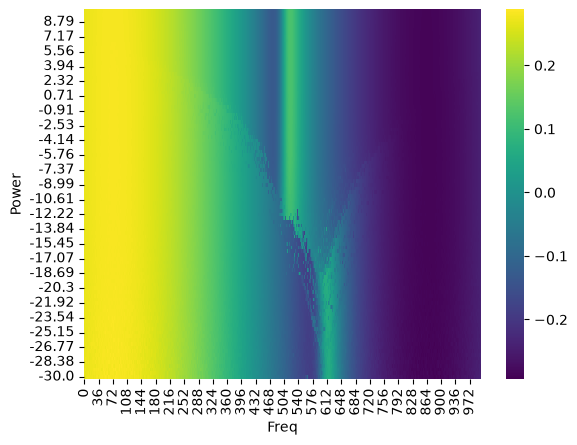

In [42]:
y0 = np.array(resonator["y0"])
y1 = np.array(resonator["y1"])
x0 = np.array(resonator["x0"])
x1 = np.array(resonator["x1"])
dim = np.array(resonator["dim_0"])

df = pd.DataFrame({
    "x": x0,
    "y": x1,
    "val": y0
})

table = df.pivot(index="x", columns="y", values="val")
table.index = np.round(table.index, 2)
sns.heatmap(table, cmap="viridis").invert_yaxis()
plt.xlabel("Freq")
plt.ylabel("Power")